### 生成数据(传统方法)

In [79]:
import csv
import random
import math

# 用户输入
number = int(input("请输入试验次数: "))
money = float(input("请输入总金额: "))
people = int(input("请输入人数: "))

# 检查人数是否过多
if people > money * 100:
    print("people is too many")
else:
    # 创建CSV文件
    with open('envelopes.csv', 'w', newline='', encoding='utf-8') as csvfile:
        writer = csv.writer(csvfile)
        
        # 写入表头
        header = ['Trial'] + [f'Person{p}' for p in range(1, people + 1)]
        writer.writerow(header)
        
        # 存储所有试验结果
        all_results = []
        
        # 执行number次试验
        for j in range(number):
            envelopes = []
            remaining_money = money
            
            for i in range(people):
                # 计算剩余人数
                remaining_people = people - i
                
                # 计算剩余钱的平均值
                avg_money = remaining_money / remaining_people
                
                # 计算最大可分配金额
                max_possible_avg = min(avg_money * 2, 
                                     remaining_money - (remaining_people - 1) * 0.01)
                min_amount = 0.01
                max_amount = max(max_possible_avg, min_amount)
                
                # 如果是最后一个人，给他所有剩余的钱
                if i == people - 1:
                    money_get = round(remaining_money, 2)
                else:
                    # 生成随机金额
                    money_get = random.uniform(min_amount, max_amount)
                    money_get = round(money_get, 2)
                
                envelopes.append(money_get)
                remaining_money -= money_get
                # 由于浮点数精度问题，确保remaining_money保持两位小数
                remaining_money = round(remaining_money, 2)
            
            # 写入当前试验结果
            row = [j + 1] + envelopes
            writer.writerow(row)
            all_results.append(envelopes)
        
        # 写入总计行（每个人的总金额）
        total_row = ['Total']
        for p in range(people):
            person_total = sum(all_results[j][p] for j in range(number))
            total_row.append(round(person_total, 2))
        writer.writerow(total_row)
        
    
    print("CSV文件已生成: envelopes.csv")

CSV文件已生成: envelopes.csv


### 导入数据
计算mean,variance,std,median,min，max

In [98]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 读取CSV数据
path = "real_sample_3.csv"
raw = pd.read_csv(path)

number = 59
people = 3
money = 15


# 2. 按行读取数据
data = raw.iloc[1:number].reset_index(drop=True)

# 3. 位次列
pos_cols = data.columns[1:people+1]

# 4. 转成长表
long_df = data[pos_cols].melt(
    var_name="position",
    value_name="amount"
).dropna()

# 提取位次编号
long_df["pos_id"] = long_df["position"].str.extract(r"(\d+)").astype(int) 

# 5. 统计信息
stats = long_df.groupby("pos_id")["amount"].agg(
    mean="mean",
    variance="var",
    std="std",
    median="median",
    min="min",
    max="max"
)

print(stats)

            mean   variance       std  median   min    max
pos_id                                                    
1       4.790702   9.720496  3.117771   4.310  0.50   9.80
2       4.886842  11.487126  3.389266   3.770  0.50  12.75
3       5.357857  11.586832  3.403944   5.035  0.16  13.38


Diffusion Model生成数据：

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 读取CSV数据
path = "generated_samples.csv"
raw = pd.read_csv(path)

# 2. 直接使用所有行，不需要额外的number参数
data = raw.copy()

# 3. 确定人数（列数）
people = data.shape[1]  # 列数代表人数
print(f"人数：{people}")

# 4. 为数据添加列名
pos_cols = [f"position_{i+1}" for i in range(people)]
data.columns = pos_cols

# 4. 转成长表
long_df = data[pos_cols].melt(
    var_name="position",
    value_name="amount"
).dropna()

# 提取位次编号
long_df["pos_id"] = long_df["position"].str.extract(r"(\d+)").astype(int) 

# 5. 统计信息
stats = long_df.groupby("pos_id")["amount"].agg(
    mean="mean",
    variance="var",
    std="std",
    median="median",
    min="min",
    max="max"
)

print(stats)

人数：10
             mean   variance       std  median   min    max
pos_id                                                     
1        9.847638  39.869192  6.314206    9.48  0.00  29.12
2        9.059740  33.185291  5.760668    8.58  0.00  29.11
3       10.774885  41.526460  6.444103   10.57  0.00  28.47
4        9.702292  38.554067  6.209192    9.20  0.06  29.62
5        9.458138  37.424807  6.117582    8.63  0.04  28.81
6        9.605906  44.038699  6.636166    9.03  0.01  39.28
7       10.313864  49.239429  7.017081    9.62  0.00  34.56
8       10.751341  54.663313  7.393464    9.71  0.00  44.97
9       10.955686  72.489608  8.514083    9.12  0.02  50.60
10       9.530511  56.593750  7.522882    7.70  0.05  49.82


#### 箱线图和散点图

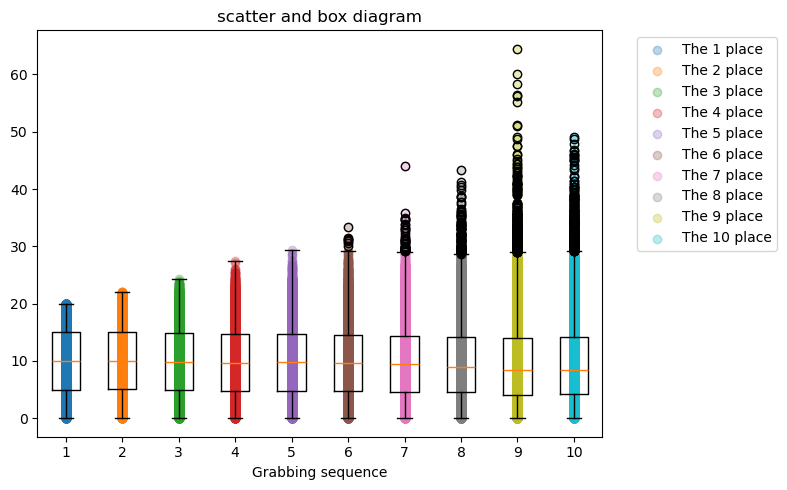

In [81]:
# 准备箱线图数据
box_data = [
    long_df[long_df["pos_id"] == pos]["amount"].values
    for pos in sorted(long_df["pos_id"].unique())
]
# 6. 散点图（不同位次不同颜色）
plt.figure(figsize=(8, 5))
plt.boxplot(box_data, showfliers=True)

for pos in sorted(long_df["pos_id"].unique()):
    y = long_df[long_df["pos_id"] == pos]["amount"]
    x = np.full(len(y), pos)
    plt.scatter(x, y, alpha=0.3, label=f"The {pos} place")

plt.xlabel("Grabbing sequence")
plt.ylabel("")
plt.title("scatter and box diagram")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

#### 画直方图（看分布形态）


蓝色为Diffusin Model生成数据的直方图，可以发现position_1不符合理论上的均匀分布，但当数据量足够大时，还是比较相似的。
这组数据 数据规模=10000，红包总额=100，人数=10

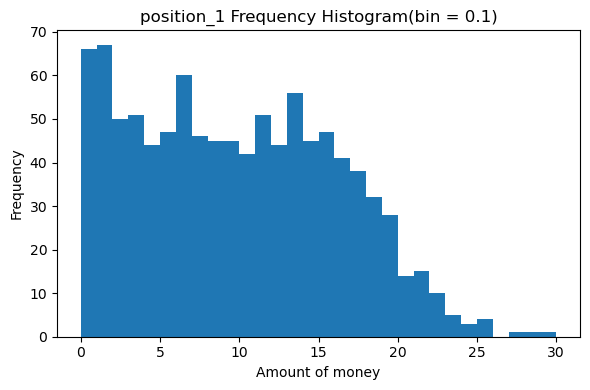

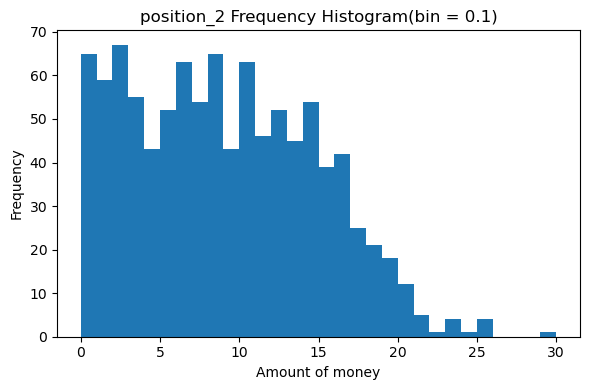

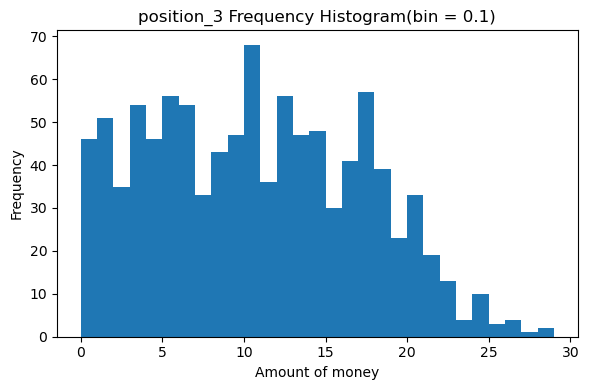

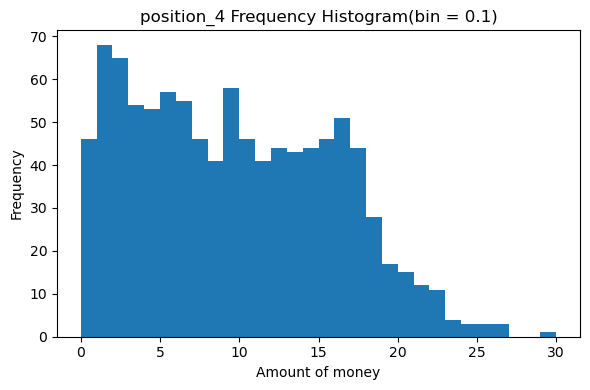

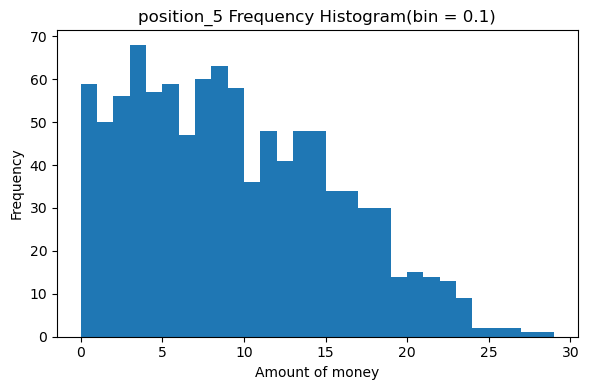

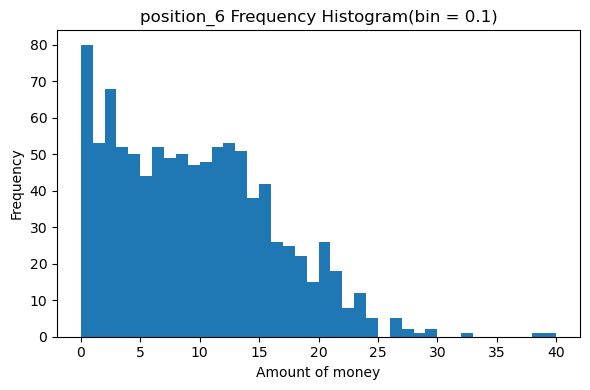

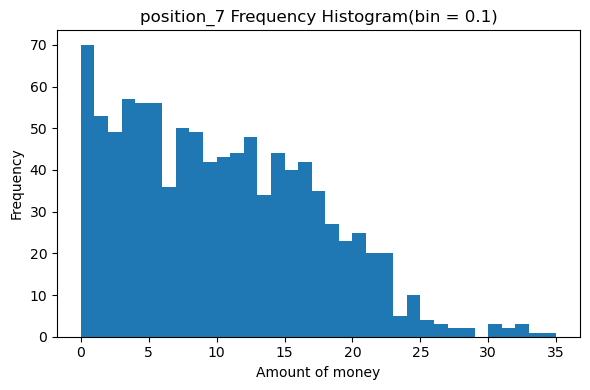

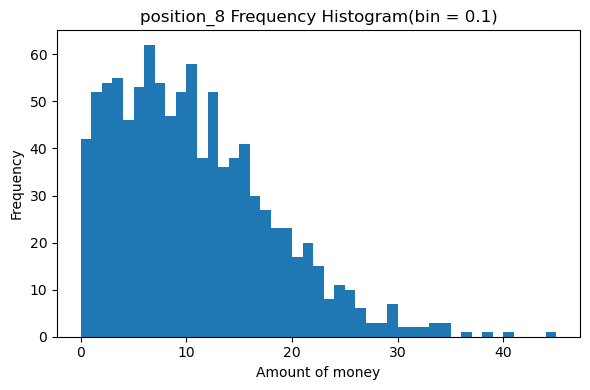

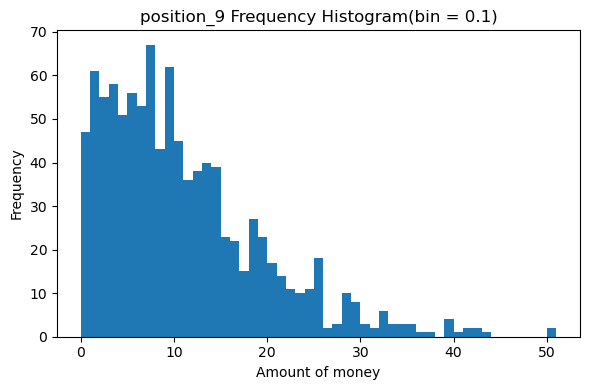

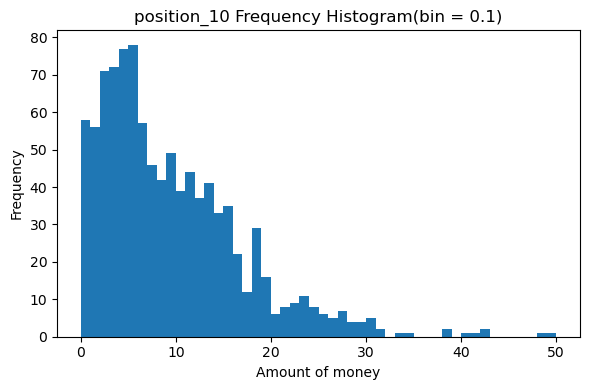

                  bin_left  bin_right  count
position   index                            
position_1 0           0.0        1.0     66
           1           1.0        2.0     67
           2           2.0        3.0     50
           3           3.0        4.0     51
           4           4.0        5.0     44


In [64]:
# 4. 直方图区间宽度
bin_width = 1

# 用于保存所有位次的频数统计结果
hist_tables = {}

for col in pos_cols:
    values = data[col].dropna().values
    
    # 构造 bins
    max_val = values.max()
    bins = np.arange(0, max_val + bin_width, bin_width)
    
    # 计算直方图频数
    counts, edges = np.histogram(values, bins=bins)
    
    # 记录频数表
    hist_df = pd.DataFrame({
        "bin_left": edges[:-1],
        "bin_right": edges[1:],
        "count": counts
    })
    hist_tables[col] = hist_df
    
    # 绘制直方图
    plt.figure(figsize=(6, 4))
    plt.hist(values, bins=bins)
    plt.xlabel("Amount of money")
    plt.ylabel("Frequency")
    plt.title(f"{col} Frequency Histogram(bin = 0.1)")
    plt.tight_layout()
    plt.show()

# 5. 合并所有位次的频数统计（方便统一分析）
all_hist_table = pd.concat(
    hist_tables,
    names=["position", "index"]
)

print(all_hist_table.head())

这是按照分布生成数据的直方图，可以与前面的直方图进行对比。最后几位的直方图已经显示出明显的长尾效应，看上去更像是指数分布，理论上也确实如此。

 P1


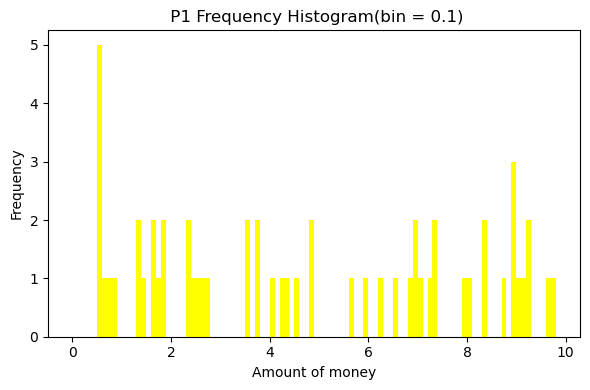

 P2


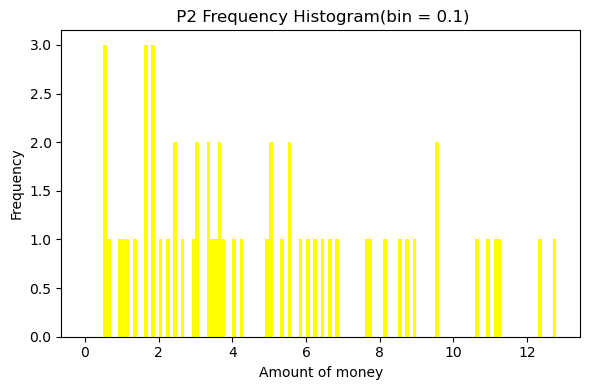

 P3 


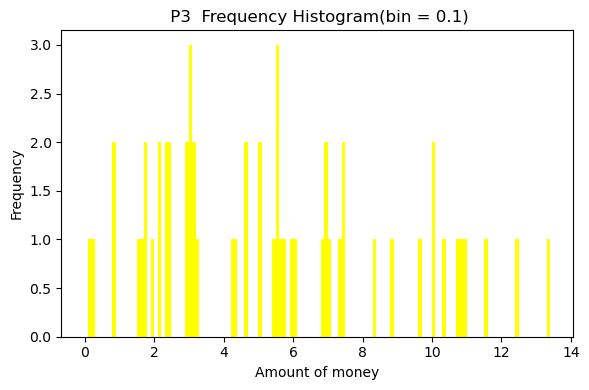

                bin_left  bin_right  count
position index                            
P1       0           0.0        0.1      0
         1           0.1        0.2      0
         2           0.2        0.3      0
         3           0.3        0.4      0
         4           0.4        0.5      0


In [99]:
# 4. 直方图区间宽度
bin_width = 0.1

# 用于保存所有位次的频数统计结果
hist_tables = {}

for col in pos_cols:
    print(col)
    values = data[col].dropna().values
    
    # 构造 bins
    max_val = values.max()
    bins = np.arange(0, max_val + bin_width, bin_width)
    
    # 计算直方图频数
    counts, edges = np.histogram(values, bins=bins)
    
    # 记录频数表
    hist_df = pd.DataFrame({
        "bin_left": edges[:-1],
        "bin_right": edges[1:],
        "count": counts
    })
    hist_tables[col] = hist_df
    
    # 绘制直方图
    plt.figure(figsize=(6, 4))
    plt.hist(values, bins=bins)
    plt.xlabel("Amount of money")
    plt.ylabel("Frequency")
    plt.title(f"{col} Frequency Histogram(bin = 0.1)")
    plt.hist(values, bins=bins, color='yellow')
    plt.tight_layout()
    plt.show()

# 5. 合并所有位次的频数统计（方便统一分析）
all_hist_table = pd.concat(
    hist_tables,
    names=["position", "index"]
)

print(all_hist_table.head())

K-S检验验证第一个人抢到的金融是否是均匀分布。

In [ ]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# 提取第一个人的数据
first_place_data = data['Person1'].dropna().values
print(first_place_data)

# 2. 执行 K-S 检验
# args=(a, range) -> loc=a, scale=b-a
# 假设我们要检验数据是否服从 U(0, money/people)
statistic, p_value = stats.kstest(first_place_data, 'uniform', args=(0, 2*money/people))

print(f"K-S 统计量: {statistic:.4f}")
print(f"P值: {p_value:.4f}")

# 3. 结果解读
alpha = 0.05
if p_value < alpha:
    print("拒绝原假设：数据不服从 Uniform(0, 2*m/n)")
else:
    print("接受原假设：数据可能服从 Uniform(0, 2*m/n)")

[ 8.15 18.8  18.44 ... 15.4   7.47  3.25]
K-S 统计量: 0.0064
P值: 0.8070
接受原假设：数据可能服从 Uniform(0, 2*m/n)


K-S检验验证最后一个人抢到的金额是否符合指数分布

对于指数分布，除了看 $P$ 值，Q-Q 图 是最专业的辅助工具。原理： 将样本的各个分位数与指数分布的理论分位数画在散点图上。判断标准： 如果数据服从指数分布，散点应该几乎在一条 45 度的斜线上。

[15.18  3.86  4.56 ...  6.9   3.32 11.27]
参数：0.0100,9.9191
K-S 统计量: 0.0878
P值: 0.0000
拒绝原假设：数据不服从指数分布


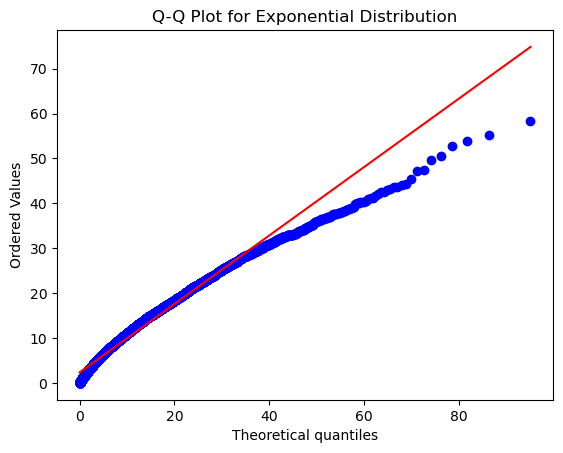

In [ ]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# 提取最后一个人的数据
last_place_data = data['Person10'].dropna().values
print(last_place_data)

# 2. 执行 K-S 检验
# 检验数据是否服从指数分布
#loc_est, scale_est = 0, people/money

#通过数据估计参数
loc_est, scale_est = stats.expon.fit(last_place_data)

statistic, p_value = stats.kstest(last_place_data, 'expon', args=(loc_est, scale_est))

print(f"参数：{loc_est:.4f},{scale_est:.4f}")
print(f"K-S 统计量: {statistic:.4f}")
print(f"P值: {p_value:.4f}")

# 3. 结果解读
alpha = 0.05
if p_value < alpha:
    print("拒绝原假设：数据不服从指数分布")
else:
    print("接受原假设：数据可能服从指数分布")

stats.probplot(last_pllace_data, dist="expon", sparams=(loc_est, scale_est), plot=plt)
plt.title("Q-Q Plot for Exponential Distribution")
plt.show()

=== 卡方拟合优度检验 (Chi-Square) ===
Chi2 统计量: 41.8991 (越小越好)
P-value:     7.5394e-01
结论: 无法拒绝原假设，理论分布与实际数据【拟合良好】。


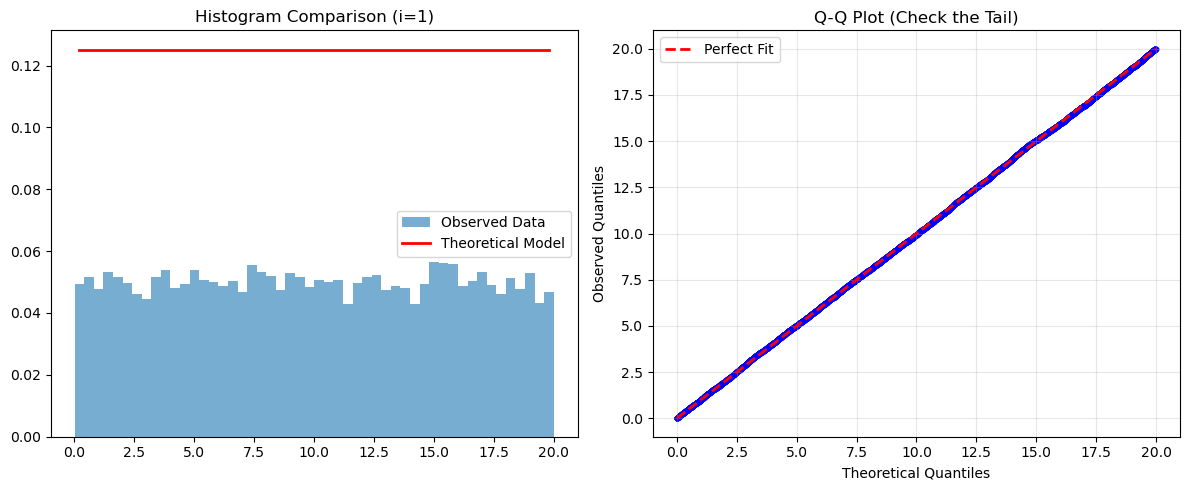

In [91]:
from scipy.stats import chisquare
import scipy.stats as stats

def chi_square_test_and_qq(data, m, n, i, bins=50):
    """
    1. 卡方拟合优度检验: 适合检验近似模型的整体形状匹配度
    2. Q-Q 图: 专门用于直观检查尾部 (Tail) 是否符合理论
    """
    
    data = np.array(data)
    
    # ==========================================
    # 第一步：准备分桶数据 (Observed)
    # ==========================================
    # 自动确定直方图的边界
    y_obs, bin_edges = np.histogram(data, bins=bins, density=False)
    
    # 计算每个桶的中心点，用于评估理论概率密度
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_widths = bin_edges[1:] - bin_edges[:-1]
    
    # ==========================================
    # 第二步：计算理论频数 (Expected)
    # ==========================================
    # 重新计算这些中心点对应的理论 PDF 值
    # --- (复用之前的 PDF 计算逻辑) ---
    if n > 1:
        breakpoint_x = (2 * m * (n - i)) / (n * (n - 1))
    else:
        breakpoint_x = m
        
    pdf_vals = np.zeros_like(bin_centers)
    
    if i == 1:
        limit = 2 * m / n
        mask = bin_centers <= limit
        pdf_vals[mask] = 1.0
    else:
        # 平坦区
        mask_flat = bin_centers <= breakpoint_x
        if breakpoint_x > 0:
            base_height = np.power(np.log(m / max(breakpoint_x, 1e-9)), i - 1)
        else:
            base_height = 0
        pdf_vals[mask_flat] = base_height
        
        # 尾部区
        mask_tail = (bin_centers > breakpoint_x) & (bin_centers < m)
        if np.any(mask_tail):
            # 防止 log(0) 或 log(负数)
            safe_x = bin_centers[mask_tail]
            safe_x[safe_x <= 0] = 1e-9
            log_term = np.log(m / safe_x)
            log_term = np.maximum(log_term, 0)
            pdf_vals[mask_tail] = np.power(log_term, i - 1)
    
    # 归一化 pdf_vals，使其积分面积为 1
    # 这里的积分近似为 sum(pdf * width)
    total_area = np.sum(pdf_vals * bin_widths)
    if total_area > 0:
        pdf_vals = pdf_vals / total_area
        
    # 计算理论频数 = 理论概率 * 总样本数
    # P(bin) ≈ PDF(center) * width
    expected_freq = pdf_vals * bin_widths * len(data)
    
    # ==========================================
    # 第三步：执行卡方检验
    # ==========================================
    # 注意：为了统计有效性，通常要求每个桶的 expected_freq >= 5
    # 这里为了代码简洁不做合并桶处理，但会输出警告
    
    # 避免除以0，将极小的期望值设为一个极小正数
    expected_freq[expected_freq == 0] = 1e-10
    
    chi2_stat, p_val = chisquare(f_obs=y_obs, f_exp=expected_freq)
    
    print(f"=== 卡方拟合优度检验 (Chi-Square) ===")
    print(f"Chi2 统计量: {chi2_stat:.4f} (越小越好)")
    print(f"P-value:     {p_val:.4e}")
    
    if p_val > 0.05:
        print("结论: 无法拒绝原假设，理论分布与实际数据【拟合良好】。")
    else:
        print("结论: 拒绝原假设 (存在偏差)。")
        print("注: 如果Chi2值不是极大，且直方图看起来很像，通常说明模型抓住了主要特征，")
        print("    但在某些局部（如拐点处）存在近似误差。")

    # ==========================================
    # 第四步：绘制 Q-Q 图 (Quantile-Quantile Plot)
    # ==========================================
    # Q-Q图是检验分布尾部（大金额区域）最直观的工具
    # 如果点落在红线上，说明分布完美匹配
    
    # 1. 对实际数据排序 (Empirical Quantiles)
    sorted_data = np.sort(data)
    n_samples = len(data)
    # 生成对应的百分位点 (0 到 1)
    quantiles = (np.arange(n_samples) + 0.5) / n_samples
    
    # 2. 计算理论分位点 (Theoretical Quantiles)
    # 由于没有解析的逆累积分布函数(PPF)，我们通过数值插值求逆
    # 先生成高分辨率 CDF
    x_grid = np.linspace(1e-4, m, 5000)
    # (复用前面的PDF计算逻辑计算grid上的pdf...)
    # --- 简化写法：为了省篇幅，这里假设 pdf_grid 已经按同样逻辑算好了 ---
    # 实际写的时候可以直接把上面的 pdf_vals 逻辑封装成函数调用
    # 这里做个简单的近似重建：
    pdf_grid = np.zeros_like(x_grid)
    if i == 1:
        pdf_grid[x_grid <= 2*m/n] = 1.0
    else:
        mask_f = x_grid <= breakpoint_x
        h = np.power(np.log(m/max(breakpoint_x,1e-9)), i-1) if breakpoint_x>0 else 0
        pdf_grid[mask_f] = h
        mask_t = (x_grid > breakpoint_x)
        if np.any(mask_t):
            pdf_grid[mask_t] = np.power(np.maximum(np.log(m/x_grid[mask_t]),0), i-1)
    
    # 归一化并计算 CDF
    pdf_grid /= np.trapz(pdf_grid, x_grid)
    cdf_grid = np.cumsum(pdf_grid) * (x_grid[1]-x_grid[0])
    cdf_grid /= cdf_grid[-1] # 强制终点为1
    
    # 创建插值函数：输入概率 p -> 输出金额 x
    from scipy.interpolate import interp1d
    inverse_cdf = interp1d(cdf_grid, x_grid, kind='linear', bounds_error=False, fill_value=(0, m))
    
    theoretical_quantiles = inverse_cdf(quantiles)
    
    # 3. 绘图
    plt.figure(figsize=(12, 5))
    
    # 子图1：直方图对比
    plt.subplot(1, 2, 1)
    plt.hist(data, bins=bins, density=True, alpha=0.6, label='Observed Data')
    plt.plot(bin_centers, pdf_vals / (bin_widths[0]*len(data)) * len(data), 'r-', lw=2, label='Theoretical Model')
    plt.title(f'Histogram Comparison (i={i})')
    plt.legend()
    
    # 子图2：Q-Q 图
    plt.subplot(1, 2, 2)
    plt.scatter(theoretical_quantiles, sorted_data, alpha=0.5, s=10, c='blue')
    # 画一条 y=x 的基准线
    max_val = max(np.max(theoretical_quantiles), np.max(sorted_data))
    plt.plot([0, max_val], [0, max_val], 'r--', lw=2, label='Perfect Fit')
    plt.xlabel('Theoretical Quantiles')
    plt.ylabel('Observed Quantiles')
    plt.title('Q-Q Plot (Check the Tail)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ==========================================
# 运行检验
# ==========================================
current_data = data['Person1'].dropna().values
chi_square_test_and_qq(current_data, m=money, n=people, i=1)